In [36]:
import matrix
from preprocess import circle_crop
from PIL import Image
from importlib import reload
import matplotlib.pyplot as plt
import numpy as np
reload(matrix)

<module 'matrix' from '/Users/jackstanley/Documents/VSCode/VSCode_old/string_draw/matrix.py'>

In [2]:
H=256
P=120

(256, 256)


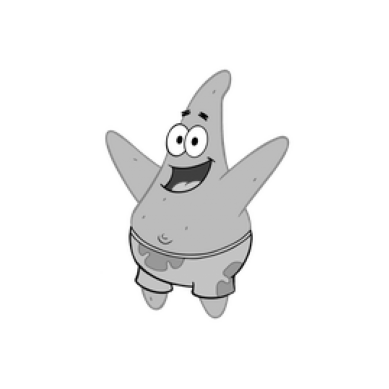

In [ ]:
target = Image.open('razer/tiger2.jpg')
target = circle_crop(target, H, 0).convert('L')
print(np.array(target).shape)
plt.imshow(target, cmap='gray')
plt.axis('off')
plt.show()


In [37]:
# M, solved = matrix.full_test(H, P, target)
M, solved = matrix.full_test(H, P, target, sparse=False, line_width=0.07)


initializing matrix of size 467927040


100%|██████████| 120/120 [00:00<00:00, 186.56it/s]


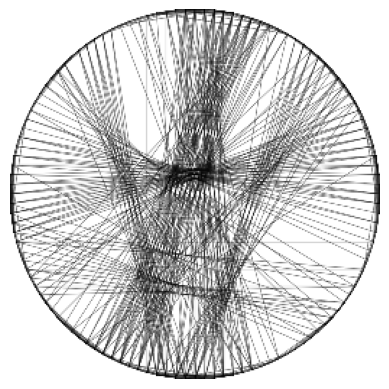

In [38]:
data = matrix.render_image(M, solved, H, threshold=0.11, line_width=0.07)
plt.imshow(data, cmap='gray')
plt.axis('off')
plt.show()


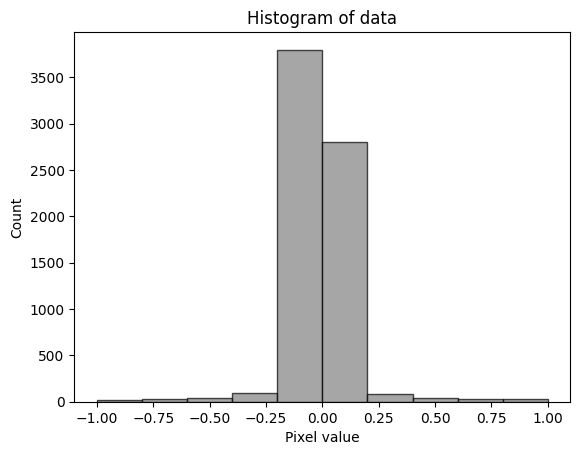

In [39]:
plt.hist(solved.flatten(), color='gray', range=(-1,1), edgecolor='black', alpha=0.7)
plt.xlabel('Pixel value')
plt.ylabel('Count')
plt.title('Histogram of data')
plt.show()

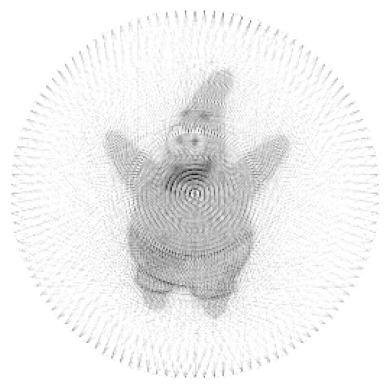

In [40]:
h = int(M.shape[0] ** 0.5)
exact = matrix.render_exact(M, solved, h)
plt.imshow(exact, cmap='gray')
plt.axis('off')
plt.show()

In [41]:
# NNLS solve + visualization
import numpy as np
import matplotlib.pyplot as plt
import matrix

x_nnls = matrix.solve_nnls(M, np.array(target), H)



In [42]:
print(x_nnls.min(), x_nnls.max())

0.0 1.059919980258062


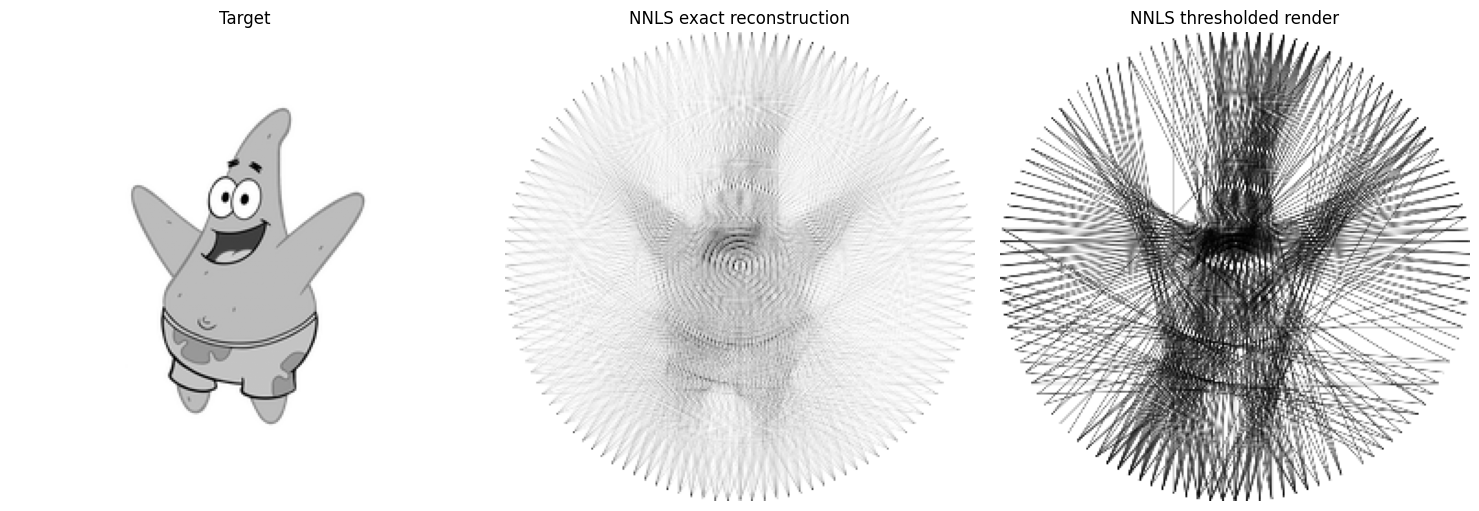

In [43]:
nnls_exact = matrix.render_exact(M, x_nnls, H)
nnls_thresholded = matrix.render_image(M, x_nnls, H, threshold=0.08, line_width=0.15)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(target, cmap="gray")
axes[0].set_title("Target")
axes[0].axis("off")

axes[1].imshow(nnls_exact, cmap="gray")
axes[1].set_title("NNLS exact reconstruction")
axes[1].axis("off")

axes[2].imshow(nnls_thresholded, cmap="gray")
axes[2].set_title("NNLS thresholded render")
axes[2].axis("off")

plt.tight_layout()
plt.show()

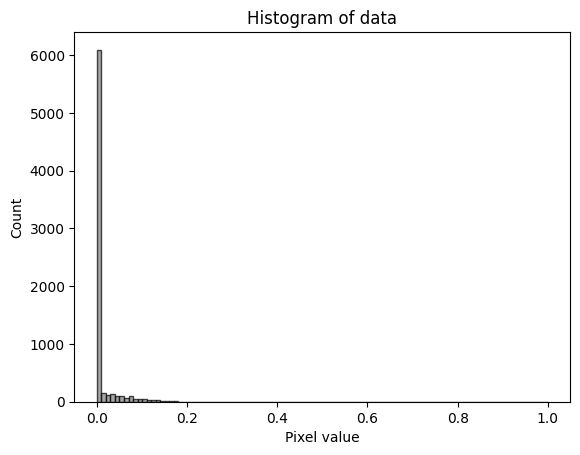

In [44]:
plt.hist(x_nnls.flatten(), color='gray', range=(0,1), edgecolor='black', alpha=0.7, bins=100)
plt.xlabel('Pixel value')
plt.ylabel('Count')
plt.title('Histogram of data')
plt.show()